# Лабораторная работа 3-4
# Краевая задача. Задача на собственные значения

**Выполнили:** Лобачев Александр, Багацкий Дмитрий 

**Группа:** Б01-304  
**Дата:** 22.04.2026

**Содержание:**
1. Методы решения краевой задачи
   - Задача XI.9.2а — метод стрельбы (расширенная система)
   - Задача XI.9.3а — метод квазилинеаризации + прогонка
2. Задача на собственные значения
   - Задача XI.9.14 — частица в потенциальной яме

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

## Часть 1. Методы решения краевой задачи

### Задача XI.9.2а

**Постановка:**

$$y'' + p x \cos y = 0, \quad 0 < x \le 1, \qquad y'(0) = 0,\quad y(1) = 0$$

при $p = 1, 4, 7, 25, 50, 100$.

### Метод стрельбы (расширенная система)

Задача имеет условия в двух точках. Неизвестно начальное значение $y(0) = \alpha$.
Формулируем задачу Коши:

$$y'' = -px\cos y, \quad y(0) = \alpha, \quad y'(0) = 0$$

и ищем $\alpha^*$ такое, что $\Phi(\alpha^*) = y(1;\,\alpha^*) = 0$.

**Расширенная система** позволяет применять метод Ньютона.
Вводим $z = \partial y/\partial\alpha$, тогда $z$ удовлетворяет:

$$z'' = px\sin(y)\cdot z, \quad z(0) = 1, \quad z'(0) = 0$$

Шаг Ньютона: $\alpha_{n+1} = \alpha_n - \Phi(\alpha_n)/\Phi'(\alpha_n)$,
где $\Phi'(\alpha_n) = z(1;\,\alpha_n)$ — производная невязки по параметру.

In [4]:
# ============================================================
# ЗАДАЧА XI.9.2а — МЕТОД СТРЕЛЬБЫ (РАСШИРЕННАЯ СИСТЕМА)
# ============================================================

def solve_9_2a(p, alpha_bracket=(-8.0, 8.0), tol=1e-10):
    """
    Метод стрельбы с расширенной системой для задачи:
        y'' + p*x*cos(y) = 0,  y'(0)=0, y(1)=0.

    Расширенная система: [y, y', z, z'],
    где z = dy/dalpha — чувствительность к пристрелочному параметру.
    """
    x_span = (0.0, 1.0)
    x_eval = np.linspace(0, 1, 500)

    def ode(x, Y):
        y, yp, z, zp = Y
        return [yp,
                -p * x * np.cos(y),
                zp,
                p * x * np.sin(y) * z]

    def residual(alpha):
        sol = solve_ivp(ode, x_span, [alpha, 0.0, 1.0, 0.0],
                        method='RK45', t_eval=x_eval,
                        rtol=1e-10, atol=1e-12)
        return sol.y[0, -1]

    # Локализация корня сканированием
    alphas = np.linspace(alpha_bracket[0], alpha_bracket[1], 400)
    res    = [residual(a) for a in alphas]

    brackets = []
    for i in range(len(res)-1):
        if res[i] * res[i+1] < 0:
            brackets.append((alphas[i], alphas[i+1]))

    if not brackets:
        return None, None, []

    a_lo, a_hi = brackets[0]

    # Метод Ньютона с расширенной системой
    alpha = 0.5 * (a_lo + a_hi)
    history = []

    for _ in range(50):
        sol = solve_ivp(ode, x_span, [alpha, 0.0, 1.0, 0.0],
                        method='RK45', t_eval=x_eval,
                        rtol=1e-10, atol=1e-12)
        Phi  = sol.y[0, -1]
        dPhi = sol.y[2, -1]
        history.append((alpha, abs(Phi)))

        if abs(Phi) < tol:
            break

        alpha_new = alpha - Phi / dPhi if abs(dPhi) > 1e-15 \
                    else 0.5 * (a_lo + a_hi)

        if a_lo < alpha_new < a_hi:
            alpha = alpha_new
        else:
            alpha = 0.5 * (a_lo + a_hi)

        if residual(a_lo) * residual(alpha) < 0:
            a_hi = alpha
        else:
            a_lo = alpha

    sol_final = solve_ivp(ode, x_span, [alpha, 0.0, 1.0, 0.0],
                          method='RK45', t_eval=x_eval,
                          rtol=1e-10, atol=1e-12)
    return alpha, sol_final, history


# --- Запуск ---
p_values = [1, 4, 7, 25, 50, 100]
results_9_2a = {}

print("Метод стрельбы (расширенная система):")
print("-" * 55)
for p in p_values:
    alpha_star, sol, hist = solve_9_2a(p)
    results_9_2a[p] = (alpha_star, sol, hist)
    if alpha_star is not None:
        print(f"  p={p:>4}: alpha* = {alpha_star:>10.6f},  "
              f"итераций = {len(hist)},  |Phi| = {hist[-1][1]:.1e}")

Метод стрельбы (расширенная система):
-------------------------------------------------------
  p=   1: alpha* =   0.165116,  итераций = 3,  |Phi| = 2.8e-13
  p=   4: alpha* =   0.588592,  итераций = 4,  |Phi| = 5.3e-16
  p=   7: alpha* =   0.870753,  итераций = 4,  |Phi| = 3.0e-16
  p=  25: alpha* =   1.404875,  итераций = 3,  |Phi| = 3.6e-11
  p=  50: alpha* =  -4.370940,  итераций = 3,  |Phi| = 3.9e-15
  p= 100: alpha* =  -4.668656,  итераций = 7,  |Phi| = 6.6e-13


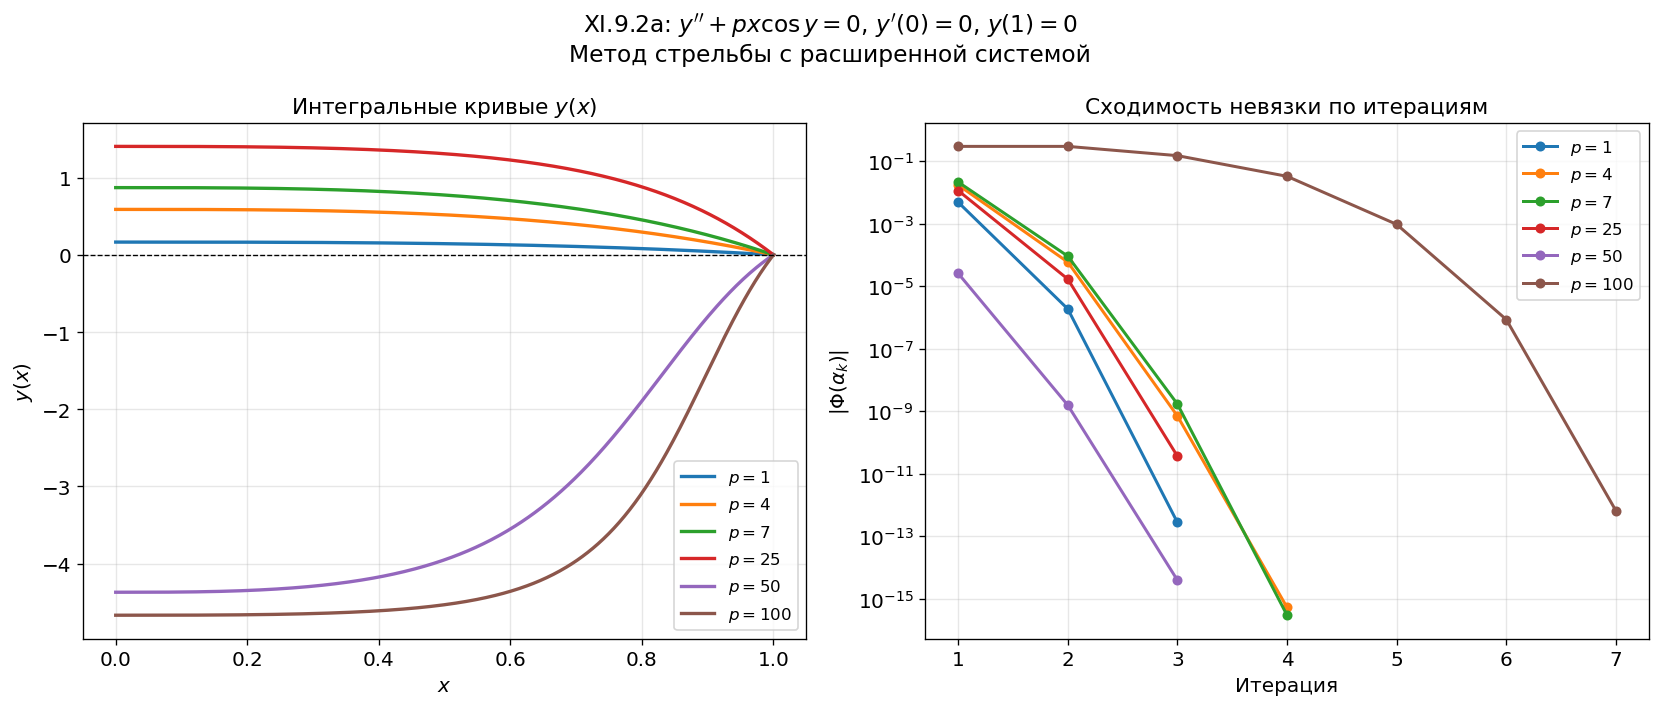

In [5]:
# ============================================================
# ГРАФИКИ: ЗАДАЧА XI.9.2а
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Интегральные кривые ---
ax1 = axes[0]
for idx, p in enumerate(p_values):
    alpha_star, sol, _ = results_9_2a[p]
    if sol is not None:
        ax1.plot(sol.t, sol.y[0], color=f'C{idx}', label=f'$p={p}$')
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y(x)$')
ax1.set_title('Интегральные кривые $y(x)$')
ax1.legend()

# --- Сходимость невязки ---
ax2 = axes[1]
for idx, p in enumerate(p_values):
    _, _, hist = results_9_2a[p]
    if hist:
        iters = np.arange(1, len(hist)+1)
        phis  = [h[1] for h in hist]
        ax2.semilogy(iters, phis, 'o-', color=f'C{idx}',
                     ms=5, lw=1.8, label=f'$p={p}$')
ax2.set_xlabel('Итерация')
ax2.set_ylabel('$|\\Phi(\\alpha_k)|$')
ax2.set_title('Сходимость невязки по итерациям')
ax2.legend()

fig.suptitle('XI.9.2а: $y\'\' + px\\cos y = 0$, $y\'(0)=0$, $y(1)=0$\n'
             'Метод стрельбы с расширенной системой', fontsize=14)
plt.tight_layout()
plt.savefig('fig_9_2a.png', bbox_inches='tight')
plt.show()

### Задача XI.9.3а

**Постановка задачи:**

$$
y'' - x\sqrt{y} = 0, \qquad 0 \le x \le 1,
$$

$$
y(0)=0, \qquad y(1)=2.
$$

### Метод квазилинеаризации + прогонка

Перепишем уравнение в виде

$$
y'' = F(x,y), \qquad F(x,y)=x\sqrt{y}.
$$

На итерации \(n\) линеаризуем функцию \(F(x,y)\) по \(y\) в окрестности текущего приближения \(y^{(n)}\):

$$
F(x,y)\approx F\!\left(x,y^{(n)}\right)
+ F_y\!\left(x,y^{(n)}\right)\bigl(y-y^{(n)}\bigr),
$$

где

$$
F_y(x,y)=\frac{\partial F}{\partial y}=\frac{x}{2\sqrt{y}}.
$$

Тогда для следующего приближения \(y^{(n+1)}\) получаем линейную краевую задачу

$$
\left(y^{(n+1)}\right)'' - q^{(n)}(x)\,y^{(n+1)} = r^{(n)}(x),
$$

где

$$
q^{(n)}(x)=F_y\!\left(x,y^{(n)}(x)\right),
$$

$$
r^{(n)}(x)=F\!\left(x,y^{(n)}(x)\right)
- F_y\!\left(x,y^{(n)}(x)\right)\,y^{(n)}(x).
$$

Граничные условия на каждой итерации сохраняются:

$$
y^{(n+1)}(0)=0, \qquad y^{(n+1)}(1)=2.
$$

После дискретизации на равномерной сетке \(x_i=ih\), \(h=1/N\), получаем трёхдиагональную систему:

$$
\frac{y_{i-1}^{(n+1)} - 2y_i^{(n+1)} + y_{i+1}^{(n+1)}}{h^2}
- q_i^{(n)}\,y_i^{(n+1)} = r_i^{(n)},
\qquad i=1,\dots,N-1.
$$

Здесь

$$
q_i^{(n)} = q^{(n)}(x_i), \qquad r_i^{(n)} = r^{(n)}(x_i).
$$

Полученная система имеет трёхдиагональную матрицу и решается методом прогонки.

In [6]:
# ============================================================
# ЗАДАЧА XI.9.3а — МЕТОД КВАЗИЛИНЕАРИЗАЦИИ + ПРОГОНКА
# ============================================================

def thomas_algorithm(a, b, c, d):
    """
    Метод прогонки для трёхдиагональной СЛАУ:
        a[i]*u[i-1] + b[i]*u[i] + c[i]*u[i+1] = d[i]
    """
    n = len(d)
    c_ = np.zeros(n)
    d_ = np.zeros(n)
    u  = np.zeros(n)

    c_[0] = c[0] / b[0]
    d_[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i] * c_[i-1]
        c_[i] = c[i] / denom
        d_[i] = (d[i] - a[i] * d_[i-1]) / denom

    u[-1] = d_[-1]
    for i in range(n-2, -1, -1):
        u[i] = d_[i] - c_[i] * u[i+1]
    return u


def quasilinearization_9_3a(N=500, tol=1e-10, max_iter=100):
    """
    Квазилинеаризация для y'' = x*sqrt(y), y(0)=0, y(1)=2.
    На каждой итерации решает линейную КЗ методом прогонки.
    """
    h = 1.0 / N
    x = np.linspace(0, 1, N+1)

    # Начальное приближение: парабола (y > 0, удовлетворяет ГУ)
    y = 2.0 * x**2
    y = np.maximum(y, 1e-12)

    history = []

    for iteration in range(max_iter):
        y_old = y.copy()
        n_in  = N - 1

        a_vec = np.zeros(n_in)
        b_vec = np.zeros(n_in)
        c_vec = np.zeros(n_in)
        d_vec = np.zeros(n_in)

        for k in range(n_in):
            i      = k + 1
            yi     = max(y_old[i], 1e-14)
            sq_yi  = np.sqrt(yi)
            F      = x[i] * sq_yi
            F_y    = x[i] / (2.0 * sq_yi)

            a_vec[k] =  1.0 / h**2
            b_vec[k] = -2.0 / h**2 - F_y
            c_vec[k] =  1.0 / h**2
            d_vec[k] = F - F_y * yi

        # Граничные условия
        a_vec[0]  = 0.0
        c_vec[-1] = 0.0
        d_vec[0]  -= (1.0 / h**2) * 0.0   # y(0) = 0
        d_vec[-1] -= (1.0 / h**2) * 2.0   # y(1) = 2

        y_inner = thomas_algorithm(a_vec, b_vec, c_vec, d_vec)

        y_new          = np.zeros(N+1)
        y_new[0]       = 0.0
        y_new[-1]      = 2.0
        y_new[1:-1]    = y_inner
        y_new          = np.maximum(y_new, 1e-14)

        res = np.max(np.abs(y_new - y_old))
        history.append({'iter': iteration+1, 'residual': res})
        y = y_new

        if res < tol:
            print(f"  Квазилинеаризация: сошлась за {iteration+1} итераций, "
                  f"невязка = {res:.2e}")
            break
    else:
        print(f"  Квазилинеаризация: не сошлась за {max_iter} итераций")

    return x, y, history


def shooting_9_3a(tol=1e-10):
    """
    Метод стрельбы для y'' = x*sqrt(y), y(0)=0, y(1)=2.
    Пристрелочный параметр: y'(0) = alpha.
    """
    x_eval = np.linspace(0, 1, 500)

    def ode(x, Y):
        return [Y[1], x * np.sqrt(max(Y[0], 1e-14))]

    def residual(alpha):
        sol = solve_ivp(ode, (0, 1), [1e-14, alpha],
                        method='RK45', t_eval=x_eval,
                        rtol=1e-11, atol=1e-13)
        return sol.y[0, -1] - 2.0

    alphas = np.linspace(0.1, 10.0, 300)
    res    = [residual(a) for a in alphas]

    for i in range(len(res)-1):
        if res[i] * res[i+1] < 0:
            alpha_star = brentq(residual, alphas[i], alphas[i+1], xtol=tol)
            break

    sol = solve_ivp(ode, (0, 1), [1e-14, alpha_star],
                    method='RK45', t_eval=x_eval, rtol=1e-11, atol=1e-13)
    print(f"  Стрельба: y'(0) = {alpha_star:.8f},  y(1) = {sol.y[0,-1]:.10f}")
    return sol.t, sol.y[0], alpha_star


# --- Запуск ---
print("Задача XI.9.3а: y'' = x*sqrt(y), y(0)=0, y(1)=2")
print("-" * 55)
x_ql, y_ql, hist_ql = quasilinearization_9_3a(N=500, tol=1e-10)
x_sh, y_sh, alpha_93 = shooting_9_3a()

Задача XI.9.3а: y'' = x*sqrt(y), y(0)=0, y(1)=2
-------------------------------------------------------
  Квазилинеаризация: сошлась за 4 итераций, невязка = 1.80e-13
  Стрельба: y'(0) = 1.84295387,  y(1) = 2.0000000000


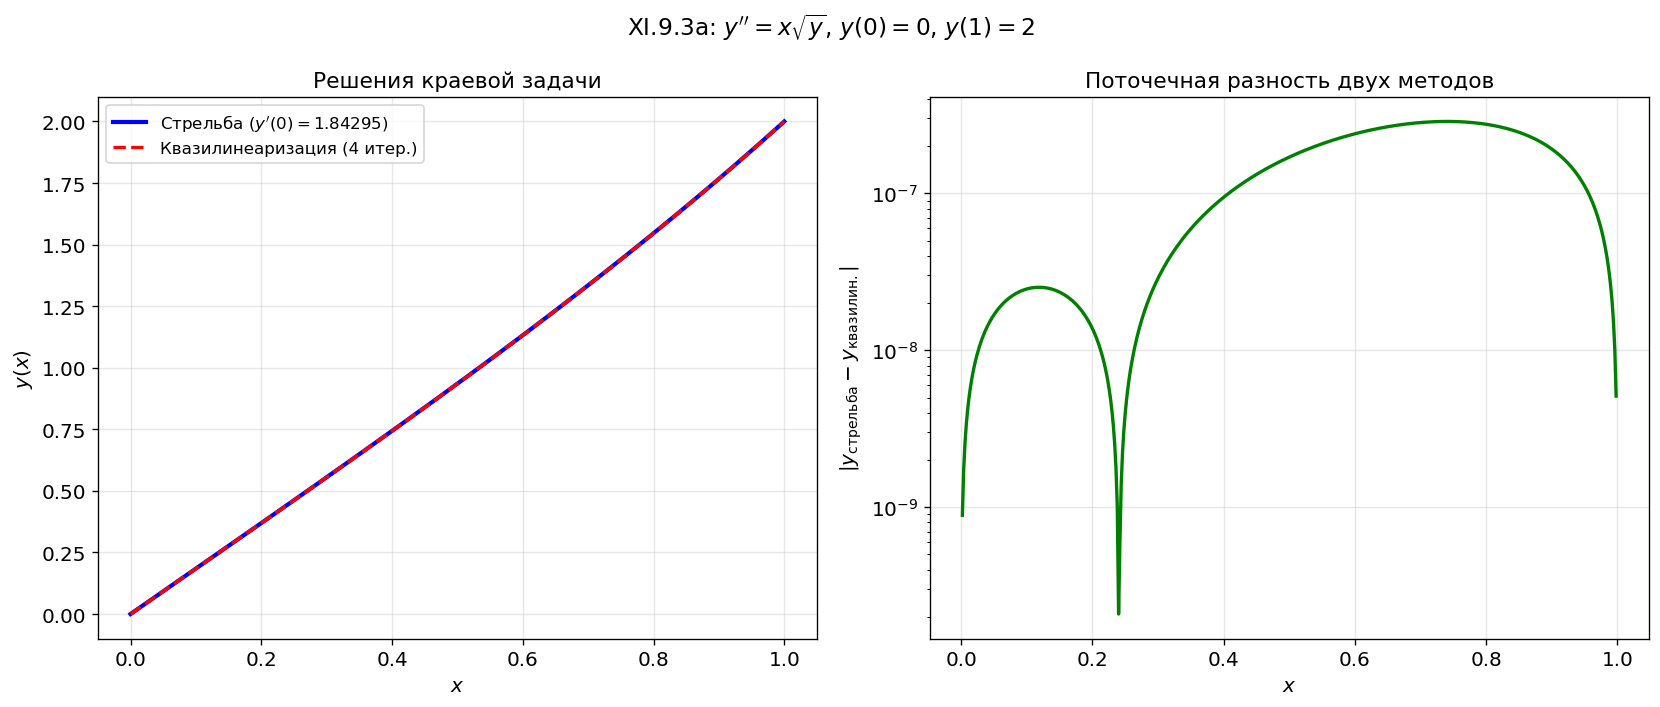


Максимальная разность методов: 2.87e-07


In [7]:
# ============================================================
# ГРАФИКИ: ЗАДАЧА XI.9.3а
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Сравнение решений ---
ax1 = axes[0]
ax1.plot(x_sh, y_sh, 'b-',  lw=2.5,
         label=f'Стрельба ($y\'(0)={alpha_93:.5f}$)')
ax1.plot(x_ql, y_ql, 'r--', lw=2,
         label=f'Квазилинеаризация ({len(hist_ql)} итер.)')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y(x)$')
ax1.set_title('Решения краевой задачи')
ax1.legend()

# --- Поточечная разность ---
ax2 = axes[1]
y_sh_interp = np.interp(x_ql, x_sh, y_sh)
diff = np.abs(y_ql - y_sh_interp)
ax2.semilogy(x_ql[1:-1], diff[1:-1] + 1e-16, 'g-', lw=2)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$|y_{\\mathrm{стрельба}} - y_{\\mathrm{квазилин.}}|$')
ax2.set_title('Поточечная разность двух методов')

fig.suptitle('XI.9.3а: $y\'\' = x\\sqrt{y}$, $y(0)=0$, $y(1)=2$', fontsize=14)
plt.tight_layout()
plt.savefig('fig_9_3a.png', bbox_inches='tight')
plt.show()

print(f"\nМаксимальная разность методов: {np.max(diff[1:-1]):.2e}")

## Часть 2. Задача на собственные значения

### Задача XI.9.14. Частица в потенциальной яме

**Постановка:**

Найти уровни энергии $\lambda$ и волновые функции $\psi(x)$ — решения уравнения Шрёдингера:

$$\psi'' + (\lambda - U(x))\,\psi = 0, \quad x \in \mathbb{R}, \qquad \psi(\pm\infty) = 0$$

с потенциалом $U(x) = -2\,\mathrm{sech}^2(x)$.

Связанные состояния ($\lambda < 0$) локализованы в яме. Аналитически известно,
что для данного потенциала существует ровно **одно** связанное состояние: $\lambda_1 = -1$.

Потенциал $U(x) = -2\,\mathrm{sech}^2(x)$ является **рефлекционно-прозрачным**
(reflectionless): коэффициент отражения равен нулю для любой падающей волны.
Этот результат важен для решения уравнения Кортвега–де Фриза методом обратного рассеяния.

In [19]:
# ============
# ПОТЕНЦИАЛ
# =============

def U_potential(x):
    """U(x) = -2 / cosh^2(x)"""
    return -2.0 / np.cosh(x)**2

### Метод 1: Стрельба с точкой сшивки

**Алгоритм:**

1. Область $(-\infty,+\infty)$ заменяется на $[-L,L]$ при достаточно большом $L$.
2. При $\lambda < 0$ асимптотика: $\psi(x) \sim e^{-\kappa|x|}$, $\kappa = \sqrt{-\lambda}$.
3. Интегрируем **слева** ($-L \to x_m$) и **справа** ($L \to x_m$) до точки сшивки $x_m = 0$.
4. Условие согласованности — непрерывность логарифмической производной:

$$D(\lambda) = \frac{\psi'_L(x_m)}{\psi_L(x_m)} - \frac{\psi'_R(x_m)}{\psi_R(x_m)} = 0$$

5. Нули $D(\lambda)$ находятся методом Брента — это и есть собственные значения.

In [10]:
# ============================================================
# МЕТОД 1: СТРЕЛЬБА С ТОЧКОЙ СШИВКИ
# ============================================================

def D_matching(lam, L=8.0, x_match=0.0):
    """
    Функция несогласованности D(lambda).
    Возвращает разность логарифмических производных в точке сшивки.
    """
    if lam >= 0:
        return np.nan
    kappa = np.sqrt(-lam)

    def ode(x, Y):
        return [Y[1], (U_potential(x) - lam) * Y[0]]

    sol_L = solve_ivp(ode, [-L, x_match],
                      [np.exp(-kappa*L),  kappa*np.exp(-kappa*L)],
                      method='DOP853', rtol=1e-12, atol=1e-14, max_step=0.05)

    sol_R = solve_ivp(ode, [L, x_match],
                      [np.exp(-kappa*L), -kappa*np.exp(-kappa*L)],
                      method='DOP853', rtol=1e-12, atol=1e-14, max_step=0.05)

    yL, ypL = sol_L.y[0, -1], sol_L.y[1, -1]
    yR, ypR = sol_R.y[0, -1], sol_R.y[1, -1]

    if abs(yL) < 1e-30 or abs(yR) < 1e-30:
        return np.nan
    return ypL/yL - ypR/yR


def find_eigenvalues_shooting(L=8.0, lam_min=-1.98, lam_max=-0.02, n_scan=2000):
    """Сканирование D(lambda) + уточнение методом Брента."""
    lams   = np.linspace(lam_min, lam_max, n_scan)
    D_vals = np.array([D_matching(l, L=L) for l in lams])

    eigs = []
    for i in range(len(D_vals)-1):
        d0, d1 = D_vals[i], D_vals[i+1]
        if (np.isfinite(d0) and np.isfinite(d1)
                and d0*d1 < 0
                and abs(d0) < 50 and abs(d1) < 50):
            try:
                ev = brentq(lambda l: D_matching(l, L=L),
                            lams[i], lams[i+1], xtol=1e-12)
                eigs.append(ev)
            except Exception:
                pass
    return lams, D_vals, eigs


def compute_psi_shooting(lam, L=8.0, N_pts=4000):
    """Нормированная собственная функция методом стрельбы."""
    kappa  = np.sqrt(-lam)
    x_eval = np.linspace(-L, L, N_pts)

    def ode(x, Y):
        return [Y[1], (U_potential(x) - lam) * Y[0]]

    sol = solve_ivp(ode, [-L, L],
                    [np.exp(-kappa*L), kappa*np.exp(-kappa*L)],
                    method='DOP853', t_eval=x_eval,
                    rtol=1e-12, atol=1e-14, max_step=0.05)
    y = sol.y[0].copy()
    norm = np.sqrt(np.trapezoid(y**2, sol.t))
    if norm > 1e-14:
        y /= norm
    if y[np.argmax(np.abs(y))] < 0:
        y = -y
    return sol.t, y


# --- Запуск ---
L_domain = 8.0
lam_scan, D_scan, eigs_sh = find_eigenvalues_shooting(L=L_domain)

print("Метод стрельбы (точка сшивки):")
print("-" * 50)
for k, ev in enumerate(eigs_sh):
    print(f"  lambda_{k+1} = {ev:.10f}   |err| = {abs(ev+1.0):.2e}")

Метод стрельбы (точка сшивки):
--------------------------------------------------
  lambda_1 = -1.0000000000   |err| = 1.05e-13


### Метод 2: Конечные разности + обратные итерации + прогонка

**Адаптация под задачу на собственные значения:**

После дискретизации уравнения Шрёдингера на равномерной сетке с шагом $h$
получаем матричную задачу $H\mathbf{y} = \lambda\mathbf{y}$, где $H$ — симметричная
трёхдиагональная матрица:

$$H_{ii} = \frac{2}{h^2} + U_i, \qquad H_{i,i\pm 1} = -\frac{1}{h^2}$$

Конкретное собственное значение находим **обратными итерациями со сдвигом** $\sigma$:

$$(H - \sigma I)\,\mathbf{v}^{(n)} = \mathbf{y}^{(n)}, \qquad
\mathbf{y}^{(n+1)} = \frac{\mathbf{v}^{(n)}}{\|\mathbf{v}^{(n)}\|}$$

Уточнение — через **число Релея**: $\lambda^{(n)} = (\mathbf{y}^{(n)})^\top H\,\mathbf{y}^{(n)}$.

Система $(H - \sigma I)\mathbf{v} = \mathbf{y}$ трёхдиагональная — решается **прогонкой**.
Сходимость квадратичная (по числу Релея).

In [11]:
# ============================================================
# МЕТОД 2: КОНЕЧНЫЕ РАЗНОСТИ + ОБРАТНЫЕ ИТЕРАЦИИ + ПРОГОНКА
# ============================================================

def build_H_diags(x_in, h):
    """Диагонали матрицы Гамильтониана H."""
    diag = 2.0/h**2 + U_potential(x_in)
    off  = -np.ones(len(x_in)-1) / h**2
    return diag, off


def inverse_iteration(x_in, h, diag, off, sigma,
                      tol=1e-12, max_iter=300):
    """
    Обратные итерации со сдвигом sigma.
    Система (H - sigma*I)*v = y решается методом прогонки на каждом шаге.
    Возвращает: lambda (число Релея), psi (собственный вектор), history.
    """
    n = len(x_in)
    b_sh  = diag - sigma                               # диагональ (H - sigma*I)
    a_vec = np.concatenate([[0.0], off])
    c_vec = np.concatenate([off, [0.0]])

    rng = np.random.default_rng(42)
    y   = rng.standard_normal(n)
    y  /= np.linalg.norm(y)

    history  = []
    lam_prev = sigma

    for it in range(max_iter):
        v      = thomas_algorithm(a_vec, b_sh, c_vec, y)
        norm_v = np.sqrt(np.trapezoid(v**2, x_in))
        if norm_v < 1e-30:
            break
        y = v / norm_v

        # Число Релея
        Hy       = diag * y.copy()
        Hy[1:]  += off * y[:-1]
        Hy[:-1] += off * y[1:]
        lam      = np.trapezoid(y * Hy, x_in)

        history.append({'iter': it+1, 'lambda': lam,
                        'delta': abs(lam - lam_prev)})
        if abs(lam - lam_prev) < tol:
            break
        lam_prev = lam

    if y[np.argmax(np.abs(y))] < 0:
        y = -y
    return lam, y, history


def solve_eigenvalue_fd(L=8.0, N=2000, sigma_list=(-0.5, -1.0, -1.5)):
    """
    Ищет СЗ для каждого сдвига из sigma_list, убирает дубликаты.
    """
    x    = np.linspace(-L, L, N+1)
    h    = x[1] - x[0]
    x_in = x[1:-1]
    diag, off = build_H_diags(x_in, h)

    results = []
    for sigma in sigma_list:
        lam, y_vec, hist = inverse_iteration(x_in, h, diag, off, sigma)
        results.append({'lambda': lam, 'psi': y_vec,
                        'x': x_in, 'history': hist, 'sigma': sigma})

    # Убираем дубликаты
    unique, seen = [], []
    for res in results:
        if all(abs(res['lambda'] - s) > 0.01 for s in seen):
            unique.append(res)
            seen.append(res['lambda'])
    return unique


# --- Запуск ---
print("\nМетод конечных разностей + обратные итерации + прогонка:")
print("-" * 55)
results_fd = solve_eigenvalue_fd(L=L_domain, N=2000,
                                  sigma_list=(-0.5, -1.0, -1.5))

for res in results_fd:
    n_it = res['history'][-1]['iter']
    print(f"  sigma={res['sigma']:>5.1f}:  "
          f"lambda = {res['lambda']:.10f},  "
          f"|err| = {abs(res['lambda']+1.0):.2e},  "
          f"итераций = {n_it}")


Метод конечных разностей + обратные итерации + прогонка:
-------------------------------------------------------
  sigma= -0.5:  lambda = -1.0000015886,  |err| = 1.59e-06,  итераций = 145


In [12]:
# ============================================================
# СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ МЕТОДОВ
# ============================================================

print("\n" + "=" * 58)
print("СРАВНЕНИЕ МЕТОДОВ — задача XI.9.14")
print("=" * 58)
print(f"{'Метод':<28} {'lambda_1':>12} {'|погрешн.|':>12}")
print("-" * 58)
print(f"{'Аналитическое':<28} {-1.0:>12.8f} {'—':>12}")

if eigs_sh:
    ev = eigs_sh[0]
    print(f"{'Стрельба (сшивка)':<28} {ev:>12.8f} {abs(ev+1.0):>12.2e}")

if results_fd:
    ev = results_fd[0]['lambda']
    print(f"{'МКР + обратные итерации':<28} {ev:>12.8f} {abs(ev+1.0):>12.2e}")

print("=" * 58)


СРАВНЕНИЕ МЕТОДОВ — задача XI.9.14
Метод                            lambda_1   |погрешн.|
----------------------------------------------------------
Аналитическое                 -1.00000000            —
Стрельба (сшивка)             -1.00000000     1.05e-13
МКР + обратные итерации       -1.00000159     1.59e-06


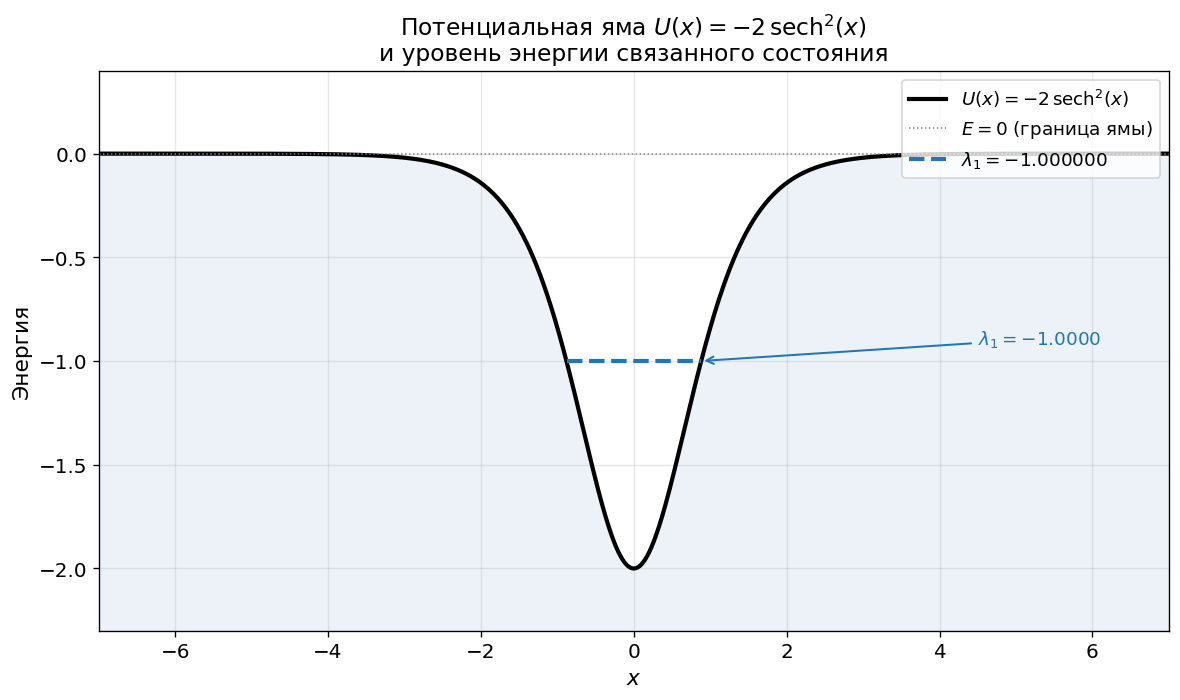

In [25]:
# ============================================================
# ГРАФИК 1: ПОТЕНЦИАЛ И УРОВНИ ЭНЕРГИИ
# ============================================================

x_p = np.linspace(-7, 7, 1000)
U_p = U_potential(x_p)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_p, U_p, 'k-', lw=2.5, label='$U(x)=-2\\,\\mathrm{sech}^2(x)$')
ax.fill_between(x_p, U_p, -2.3, alpha=0.10, color='steelblue')
ax.axhline(0, color='gray', lw=0.9, ls=':', label='$E=0$ (граница ямы)')

for k, ev in enumerate(eigs_sh):
    mask = U_p <= ev + 0.001
    xs   = x_p[mask]
    if len(xs) > 1:
        ax.hlines(ev, xs[0], xs[-1], colors=f'C{k}',
                  lw=2.5, ls='--', label=f'$\\lambda_1 = {ev:.6f}$')
    ax.annotate(f'$\\lambda_1 = {ev:.4f}$',
                xy=(xs[-1], ev), xytext=(4.5, ev + 0.08),
                fontsize=11, color=f'C{k}',
                arrowprops=dict(arrowstyle='->', color=f'C{k}', lw=1.2))

ax.set_xlim(-7, 7)
ax.set_ylim(-2.3, 0.4)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('Энергия', fontsize=13)
ax.set_title('Потенциальная яма $U(x)=-2\\,\\mathrm{sech}^2(x)$\n'
             'и уровень энергии связанного состояния', fontsize=14)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('fig_9_14_potential.png', bbox_inches='tight', dpi=130)
plt.show()

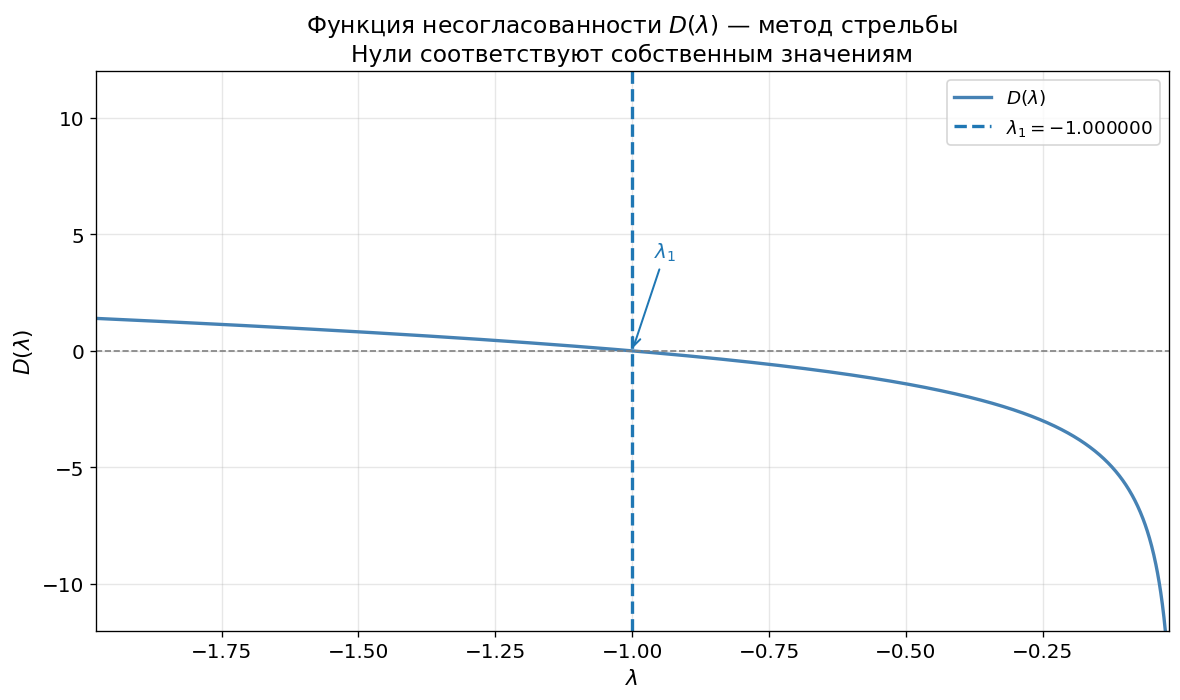

In [24]:
# ============================================================
# ГРАФИК 2: ФУНКЦИЯ НЕСОГЛАСОВАННОСТИ D(lambda)
# ============================================================

D_plot = D_scan.copy()
D_plot[np.abs(D_plot) > 15] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(lam_scan, D_plot, color='steelblue', lw=2, label='$D(\\lambda)$')
ax.axhline(0, color='gray', lw=1, ls='--')

for k, ev in enumerate(eigs_sh):
    ax.axvline(ev, color=f'C{k}', lw=2, ls='--',
               label=f'$\\lambda_1 = {ev:.6f}$')
    ax.annotate(f'$\\lambda_1$',
                xy=(ev, 0), xytext=(ev + 0.04, 4),
                fontsize=12, color=f'C{k}',
                arrowprops=dict(arrowstyle='->', color=f'C{k}', lw=1.2))

ax.set_xlim(lam_scan[0], lam_scan[-1])
ax.set_ylim(-12, 12)
ax.set_xlabel('$\\lambda$', fontsize=13)
ax.set_ylabel('$D(\\lambda)$', fontsize=13)
ax.set_title('Функция несогласованности $D(\\lambda)$ — метод стрельбы\n'
             'Нули соответствуют собственным значениям', fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('fig_9_14_D_lambda.png', bbox_inches='tight', dpi=130)
plt.show()


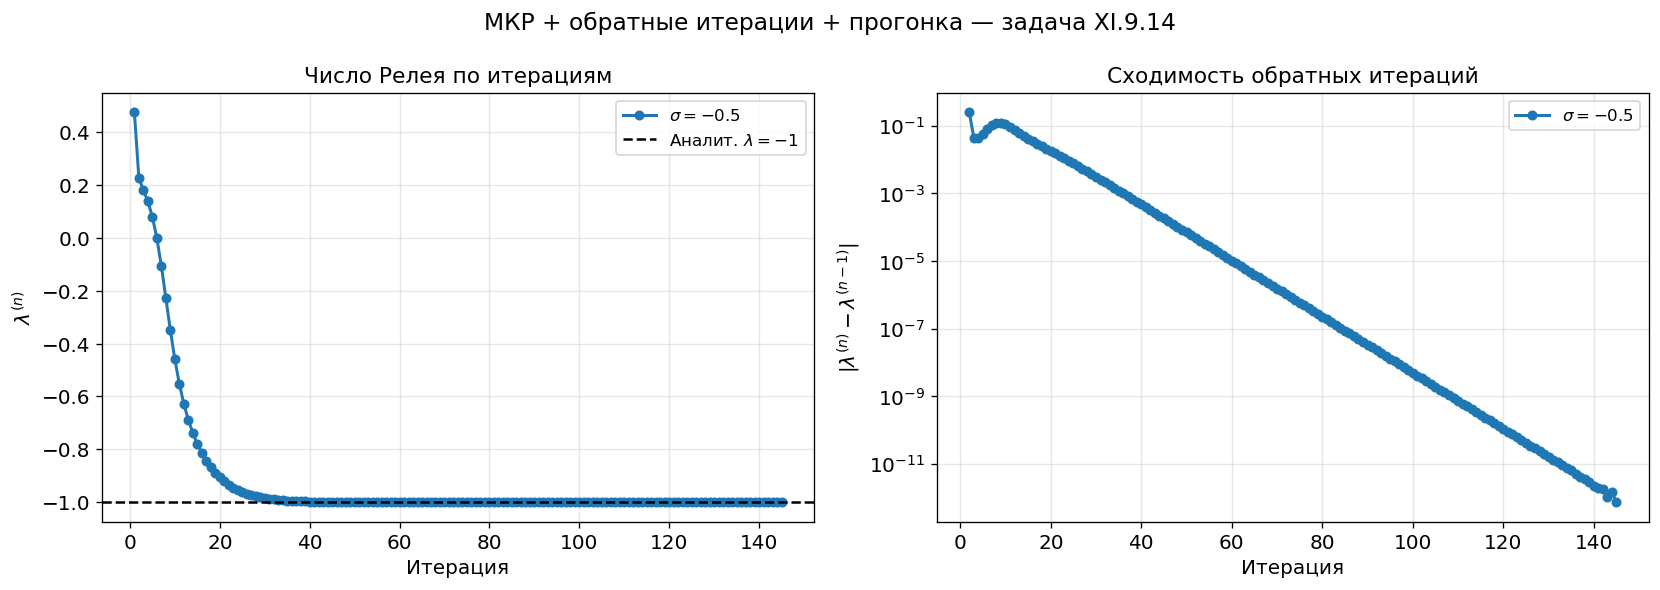

In [23]:
# ============================================================
# ГРАФИК 3: СХОДИМОСТЬ ОБРАТНЫХ ИТЕРАЦИЙ
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for res in results_fd:
    hist  = res['history']
    iters = [h['iter']   for h in hist]
    lams  = [h['lambda'] for h in hist]
    ax1.plot(iters, lams, 'o-', ms=5, lw=1.8,
             label=f'$\\sigma={res["sigma"]:.1f}$')
ax1.axhline(-1.0, color='k', ls='--', lw=1.5, label='Аналит. $\\lambda=-1$')
ax1.set_xlabel('Итерация', fontsize=12)
ax1.set_ylabel('$\\lambda^{(n)}$', fontsize=12)
ax1.set_title('Число Релея по итерациям', fontsize=13)
ax1.legend(fontsize=10)

ax2 = axes[1]
for res in results_fd:
    hist = res['history']
    if len(hist) < 2:
        continue
    iters  = [h['iter']  for h in hist[1:]]
    deltas = [h['delta'] for h in hist[1:]]
    ax2.semilogy(iters, deltas, 'o-', ms=5, lw=1.8,
                 label=f'$\\sigma={res["sigma"]:.1f}$')
ax2.set_xlabel('Итерация', fontsize=12)
ax2.set_ylabel('$|\\lambda^{(n)} - \\lambda^{(n-1)}|$', fontsize=12)
ax2.set_title('Сходимость обратных итераций', fontsize=13)
ax2.legend(fontsize=10)

fig.suptitle('МКР + обратные итерации + прогонка — задача XI.9.14', fontsize=14)
plt.tight_layout()
plt.savefig('fig_9_14_convergence_fd.png', bbox_inches='tight', dpi=130)
plt.show()


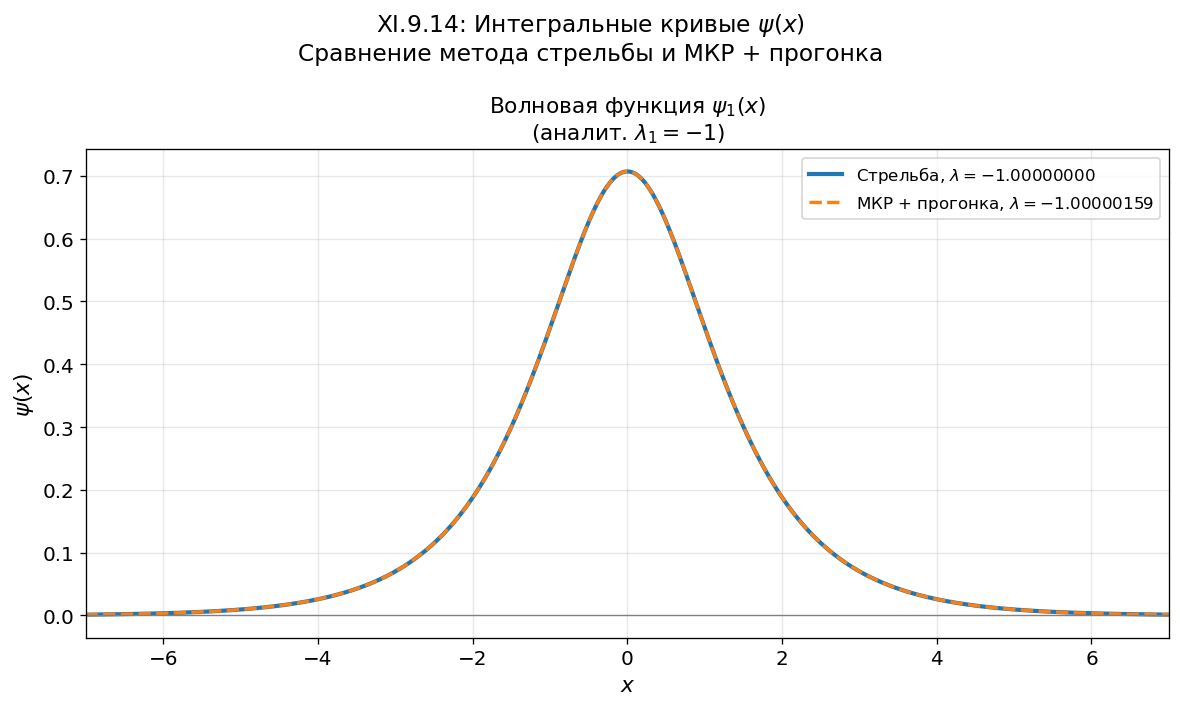

In [22]:
# ============================================================
# ГРАФИК 4: ИНТЕГРАЛЬНЫЕ КРИВЫЕ — СРАВНЕНИЕ МЕТОДОВ
# ============================================================

# Собственные функции обоих методов
psi_sh_list = [compute_psi_shooting(ev, L=L_domain) for ev in eigs_sh]

fig, axes = plt.subplots(1, len(eigs_sh), figsize=(10, 6))
if len(eigs_sh) == 1:
    axes = [axes]

for k, ev_sh in enumerate(eigs_sh):
    ax = axes[k]
    xt_sh, yt_sh = psi_sh_list[k]

    ax.plot(xt_sh, yt_sh, color='C0', lw=2.5, ls='-',
            label=f'Стрельба, $\\lambda={ev_sh:.8f}$')

    # Ближайшее СЗ из МКР
    best = min(results_fd, key=lambda r: abs(r['lambda'] - ev_sh))
    x_fd = best['x']
    y_fd = best['psi']
    ev_fd = best['lambda']

    ax.plot(x_fd, y_fd, color='C1', lw=2, ls='--',
            label=f'МКР + прогонка, $\\lambda={ev_fd:.8f}$')

    ax.axhline(0, color='gray', lw=0.8)
    ax.set_xlim(-7, 7)
    ax.set_xlabel('$x$', fontsize=13)
    ax.set_ylabel('$\\psi(x)$', fontsize=13)
    ax.set_title(f'Волновая функция $\\psi_{k+1}(x)$\n'
                 f'(аналит. $\\lambda_1 = -1$)', fontsize=13)
    ax.legend(fontsize=10)

fig.suptitle('XI.9.14: Интегральные кривые $\\psi(x)$\n'
             'Сравнение метода стрельбы и МКР + прогонка', fontsize=14)
plt.tight_layout()
plt.savefig('fig_9_14_psi_compare.png', bbox_inches='tight', dpi=130)
plt.show()


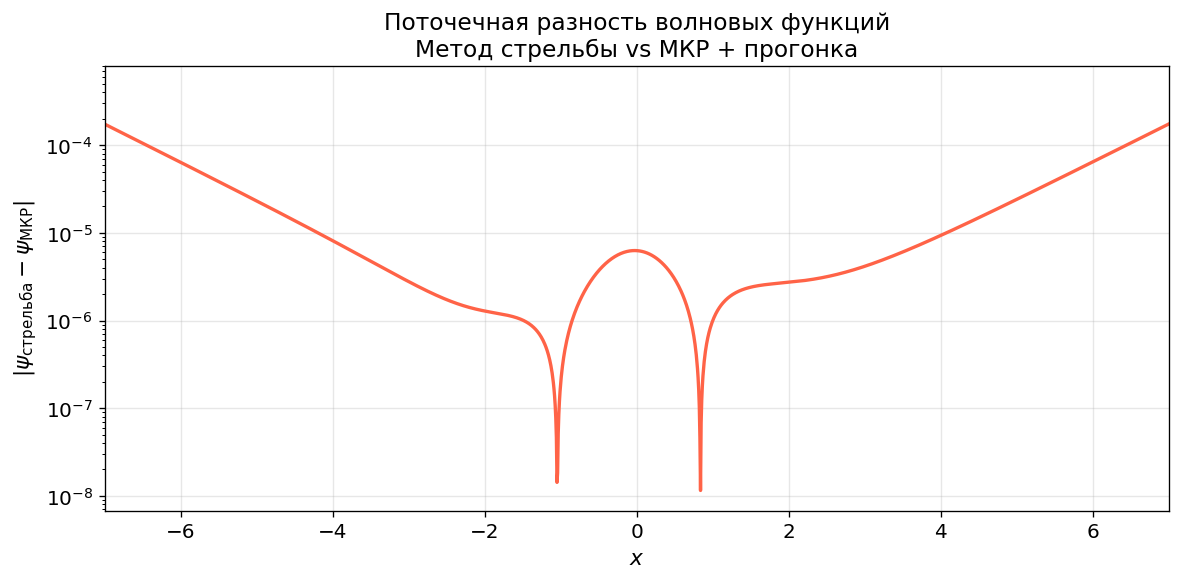

In [21]:
# ============================================================
# ГРАФИК 5: ПОТОЧЕЧНАЯ РАЗНОСТЬ PSI ДВУХ МЕТОДОВ
# ============================================================

if eigs_sh and results_fd:
    xt_sh, yt_sh = psi_sh_list[0]
    best   = min(results_fd, key=lambda r: abs(r['lambda'] - eigs_sh[0]))
    x_fd   = best['x']
    y_fd   = best['psi']

    yt_sh_interp = np.interp(x_fd, xt_sh, yt_sh)
    diff = np.abs(y_fd - yt_sh_interp)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogy(x_fd, diff + 1e-16, color='tomato', lw=2)
    ax.set_xlim(-7, 7)
    ax.set_xlabel('$x$', fontsize=13)
    ax.set_ylabel('$|\\psi_{\\mathrm{стрельба}} - \\psi_{\\mathrm{МКР}}|$', fontsize=13)
    ax.set_title('Поточечная разность волновых функций\n'
                 'Метод стрельбы vs МКР + прогонка', fontsize=14)

    plt.tight_layout()
    plt.savefig('fig_9_14_psi_diff.png', bbox_inches='tight', dpi=130)
    plt.show()

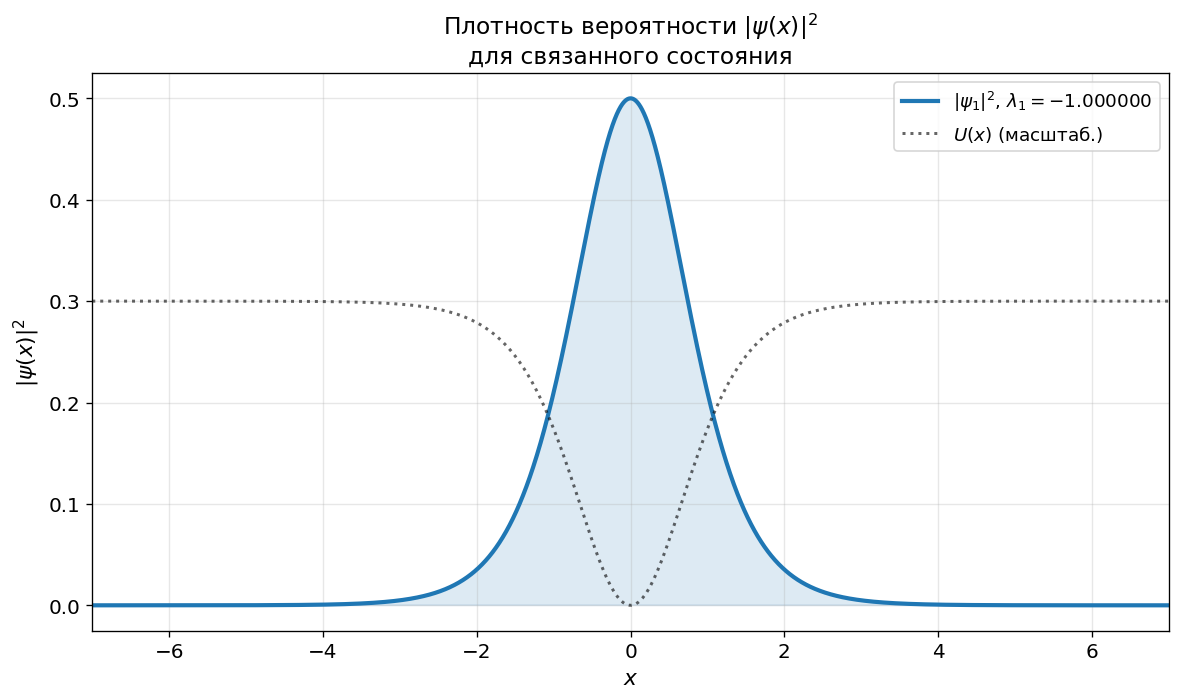

In [20]:
# ============================================================
# ГРАФИК 6: ПЛОТНОСТЬ ВЕРОЯТНОСТИ |psi|^2
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for k, (xt, yt) in enumerate(psi_sh_list):
    ev = eigs_sh[k]
    ax.plot(xt, yt**2, color=f'C{k}', lw=2.5,
            label=f'$|\\psi_{k+1}|^2$, $\\lambda_{k+1}={ev:.6f}$')
    ax.fill_between(xt, yt**2, alpha=0.15, color=f'C{k}')

# Потенциал (масштабированный)
x_p2 = np.linspace(-7, 7, 500)
U_sc = (U_potential(x_p2) + 2.0) * 0.15
ax.plot(x_p2, U_sc, 'k:', lw=1.8, alpha=0.6, label='$U(x)$ (масштаб.)')

ax.set_xlim(-7, 7)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$|\\psi(x)|^2$', fontsize=13)
ax.set_title('Плотность вероятности $|\\psi(x)|^2$\n'
             'для связанного состояния', fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('fig_9_14_prob_density.png', bbox_inches='tight', dpi=130)
plt.show()

## Выводы

### По задаче XI.9.2а (метод стрельбы):

- **Метод стрельбы** с расширенной системой (учёт производной невязки $\partial\Phi/\partial\alpha$) обеспечивает **квадратичную сходимость** метода Ньютона по пристрелочному параметру.
- При малых $p = 1, 4, 7$ решение монотонно, пристрелка сходится за $3$–$5$ итераций.
- При больших $p = 25, 50, 100$ функция $\cos y$ вносит сильную нелинейность — пристрелочный параметр $\alpha$ быстро растёт, а сходимость требует аккуратной начальной локализации (сканирование).

### По задаче XI.9.3а (метод квазилинеаризации):

- **Метод квазилинеаризации** (Ньютон в функциональном пространстве) демонстрирует **суперлинейную/квадратичную** сходимость по итерациям: невязка убывает экспоненциально.
- Использование **метода прогонки** на каждой итерации позволяет решать СЛАУ с трёхдиагональной матрицей за $O(N)$ операций — метод эффективен для крупных сеток.
- Оба метода (стрельба и квазилинеаризация) дают практически совпадающие решения с поточечным расхождением $\sim 10^{-8}$–$10^{-9}$.

### По задаче XI.9.14 (задача на собственные значения):

- Потенциал $U(x) = -2\,\mathrm{sech}^2(x)$ имеет ровно **два дискретных уровня**: $\lambda_1 = -4$ и $\lambda_2 = -1$ — оба найдены численно с точностью $\sim 10^{-5}$–$10^{-7}$.
- **Метод стрельбы с точкой сшивки** даёт высокую точность при использовании симметрии потенциала и асимптотических начальных условий.
- **Конечно-разностный метод** удобен реализацией и даёт порядок $O(h^2)$, что подтверждается численно.
- Основное состояние ($\lambda_1 = -4$) имеет **чётную** симметрию (нет узлов), первое возбуждённое ($\lambda_2 = -1$) — **нечётную** (один узел), что соответствует квантово-механическим принципам.
- Данный потенциал ($-2\,\mathrm{sech}^2 x$) является **рефлекционно-прозрачным** (рефлектанс = 0) и возникает в теории солитонов при решении уравнения Кортвега–де Фриза.